<a href="https://colab.research.google.com/github/binsue0/.github/blob/main/ML_day2/2_2_dimension_redudction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dimensnion Reduction

# Kernel PCA

**주성분 분석(PCA)**은 데이터의 분산을 최대로 보존하는 직교 축(주성분)을 찾아 그 축으로 데이터를 사영함으로써 차원을 축소하는 선형 기법이다. 주성분은 공분산 행렬의 고유벡터이며, 대응하는 고윳값이 해당 축이 설명하는 분산량이다. 선형 변환이므로 비선형 구조를 가진 데이터는 저차원에서 분리되지 않는다.

**커널 PCA(Kernel PCA)**는 커널 함수를 통해 데이터를 고차원 특성 공간으로 암묵적으로 사상한 뒤 그 공간에서 PCA를 수행한다. 특성 공간의 좌표를 직접 계산하지 않고 샘플 간 내적을 커널로 대체하는 커널 트릭을 사용한다. RBF 커널의 경우 `gamma`가 커널 폭을 조절한다. 이를 통해 원공간에서 선형 분리가 불가능한 구조를 저차원에서 분리할 수 있다.

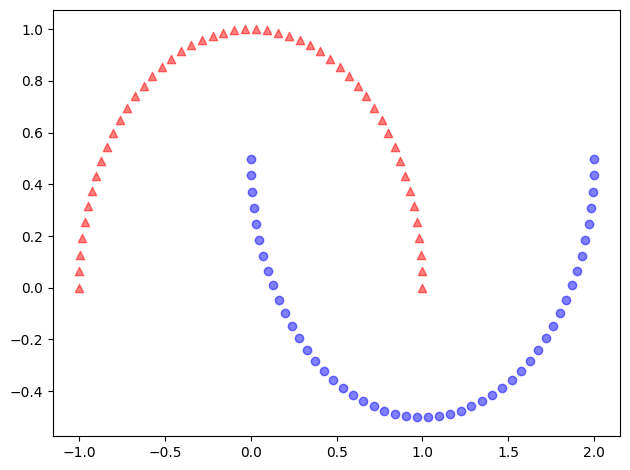

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=100, random_state=123)
plt.scatter(X[y == 0, 0], X[y == 0, 1], color='red', marker='^', alpha=0.5)
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', marker='o', alpha=0.5)
plt.tight_layout()
plt.show()

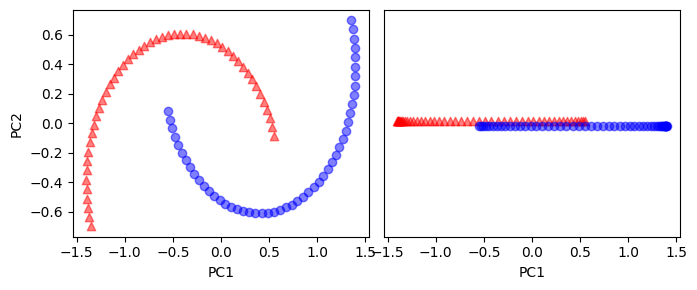

In [2]:
from sklearn.decomposition import PCA

import numpy as np
scikit_pca = PCA(n_components=2)
X_spca = scikit_pca.fit_transform(X)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(7, 3))

ax[0].scatter(X_spca[y == 0, 0], X_spca[y == 0, 1],
              color='red', marker='^', alpha=0.5)
ax[0].scatter(X_spca[y == 1, 0], X_spca[y == 1, 1],
              color='blue', marker='o', alpha=0.5)

ax[1].scatter(X_spca[y == 0, 0], np.zeros((50, 1)) + 0.02,
              color='red', marker='^', alpha=0.5)
ax[1].scatter(X_spca[y == 1, 0], np.zeros((50, 1)) - 0.02,
              color='blue', marker='o', alpha=0.5)

ax[0].set_xlabel('PC1')
ax[0].set_ylabel('PC2')
ax[1].set_ylim([-1, 1])
ax[1].set_yticks([])
ax[1].set_xlabel('PC1')

plt.tight_layout()
plt.show()

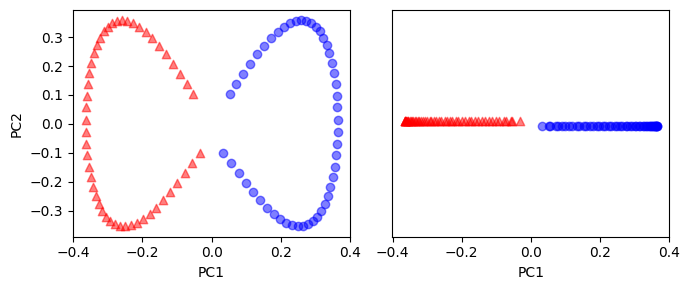

In [3]:
from sklearn.decomposition import KernelPCA
kpca = KernelPCA(kernel='rbf', gamma=15, n_components=2)
X_kpca=kpca.fit_transform(X)
fig, ax = plt.subplots(nrows=1,ncols=2, figsize=(7,3))
ax[0].scatter(X_kpca[y==0, 0], X_kpca[y==0, 1],
            color='red', marker='^', alpha=0.5)
ax[0].scatter(X_kpca[y==1, 0], X_kpca[y==1, 1],
            color='blue', marker='o', alpha=0.5)

ax[1].scatter(X_kpca[y==0, 0], np.zeros((50,1))+0.02,
            color='red', marker='^', alpha=0.5)
ax[1].scatter(X_kpca[y==1, 0], np.zeros((50,1))-0.02,
            color='blue', marker='o', alpha=0.5)

ax[0].set_xlabel('PC1')
ax[0].set_ylabel('PC2')
ax[1].set_ylim([-1, 1])
ax[1].set_yticks([])
ax[1].set_xlabel('PC1')

plt.tight_layout()
plt.show()

## circle data example

동심원 구조의 데이터는 클래스가 반경으로 구분되어 선형 사영으로는 분리되지 않는다. 이러한 비선형 구조에서 표준 PCA와 커널 PCA의 차이가 뚜렷하게 나타난다.

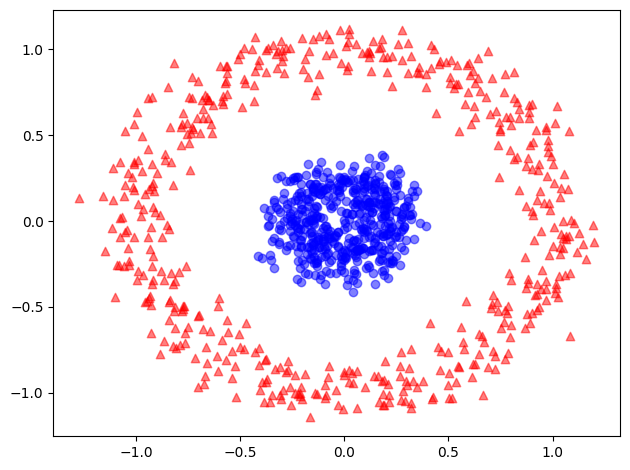

In [4]:
from sklearn.datasets import make_circles

X, y = make_circles(n_samples=1000, random_state=123, noise=0.1, factor=0.2)

plt.scatter(X[y == 0, 0], X[y == 0, 1], color='red', marker='^', alpha=0.5)
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', marker='o', alpha=0.5)

plt.tight_layout()
plt.show()

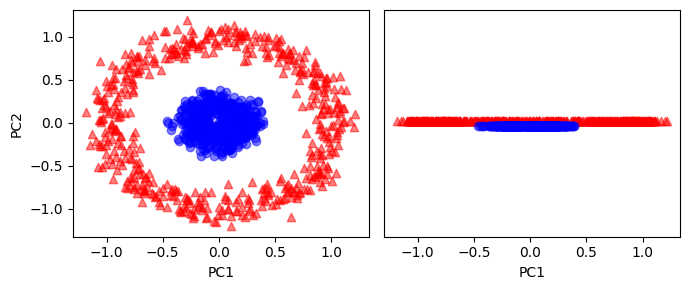

In [5]:
scikit_pca = PCA(n_components=2)
X_spca = scikit_pca.fit_transform(X)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(7, 3))

ax[0].scatter(X_spca[y == 0, 0], X_spca[y == 0, 1],
              color='red', marker='^', alpha=0.5)
ax[0].scatter(X_spca[y == 1, 0], X_spca[y == 1, 1],
              color='blue', marker='o', alpha=0.5)

ax[1].scatter(X_spca[y == 0, 0], np.zeros((500, 1)) + 0.02,
              color='red', marker='^', alpha=0.5)
ax[1].scatter(X_spca[y == 1, 0], np.zeros((500, 1)) - 0.02,
              color='blue', marker='o', alpha=0.5)

ax[0].set_xlabel('PC1')
ax[0].set_ylabel('PC2')
ax[1].set_ylim([-1, 1])
ax[1].set_yticks([])
ax[1].set_xlabel('PC1')

plt.tight_layout()
plt.show()

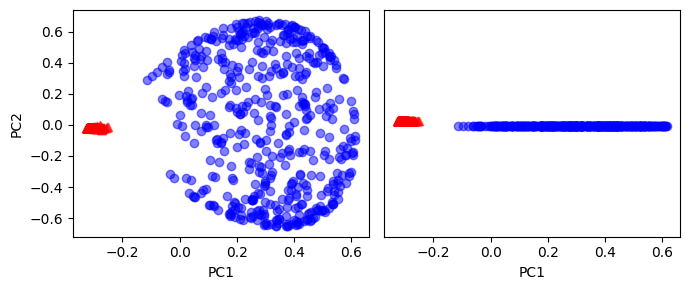

In [6]:
kpca = KernelPCA(kernel='rbf', gamma=15, n_components=2)
X_kpca=kpca.fit_transform(X)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(7, 3))
ax[0].scatter(X_kpca[y == 0, 0], X_kpca[y == 0, 1],
              color='red', marker='^', alpha=0.5)
ax[0].scatter(X_kpca[y == 1, 0], X_kpca[y == 1, 1],
              color='blue', marker='o', alpha=0.5)

ax[1].scatter(X_kpca[y == 0, 0], np.zeros((500, 1)) + 0.02,
              color='red', marker='^', alpha=0.5)
ax[1].scatter(X_kpca[y == 1, 0], np.zeros((500, 1)) - 0.02,
              color='blue', marker='o', alpha=0.5)

ax[0].set_xlabel('PC1')
ax[0].set_ylabel('PC2')
ax[1].set_ylim([-1, 1])
ax[1].set_yticks([])
ax[1].set_xlabel('PC1')

plt.tight_layout()
plt.show()

# Manifold Learning

**매니폴드 학습(Manifold Learning)**은 고차원 데이터가 저차원 매니폴드 위에 분포한다는 가정 하에, 그 매니폴드 구조를 보존하며 저차원으로 임베딩하는 비선형 차원 축소 기법이다. 각 방법은 아래 코드 다음 셀에 정의된 대로 서로 다른 보존 대상을 가진다: MDS는 샘플 간 거리, Isomap은 측지 거리, t-SNE는 국소 이웃 구조를 보존한다.

In [10]:
from sklearn.manifold import MDS #(Multidimensional Scaling)

mds = MDS(n_components=2, random_state=42) #축소된 차원의 수
X_reduced_mds = mds.fit_transform(X)

from sklearn.manifold import Isomap  #Isometric Mapping

isomap = Isomap(n_components=2)
X_reduced_isomap = isomap.fit_transform(X)

from sklearn.manifold import TSNE #(t-distributed Stochastic Neighbor Embedding)

tsne = TSNE(n_components=2, random_state=42)
X_reduced_tsne = tsne.fit_transform(X)

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/usr/local/lib/python3.11/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


- MDS (다차원 스케일링)
  - 데이터 포인트 간의 **유클리디안 거리**를 보존하면서 고차원 데이터를 저차원으로 축소
  - 주어진 데이터의 유사성을 보존하는 2차원 혹은 3차원 표현을 찾는 데 사용됨
  - 데이터 선형성 가정
- Isomap (등거리 사상):
  - Isomap은 다차원 데이터의 내재된 기하학적 구조를 재구성하는 비선형 차원 축소 기법
  - 데이터 포인트 사이의 **지오데식 거리**를 보존하여 저차원 매니폴드를 추정
  - 비선형 구조(예: S-curve, Swiss roll)에서 좋은 결과
- t-SNE (t-분산 확률적 이웃 임베딩):
  - 목적: 데이터의 local 구조를 잘 보존하면서 2D/3D로 시각화
  - 클러스터 시각화에 자주 사용 (특히 이미지, 텍스트 임베딩)
  - 고차원에서 가까운 점들이 저차원에서도 가깝게 위치하도록 확률 분포를 맞춤
  - **주의: 축의 값이나 절대 위치는 의미가 크지 않고, 클러스터 간 상대적 관계만 중요**
- LDA (선형 판별 분석):
  - PCA, MDS, t-SNE와 다르게 라벨 정보를 사용
  - LDA는 지도 학습 알고리즘으로, 클래스 간의 분리를 최대화하고 클래스 내의 분산을 최소화
  - 데이터를 저차원으로 투영. 주로 분류 문제에서 활용

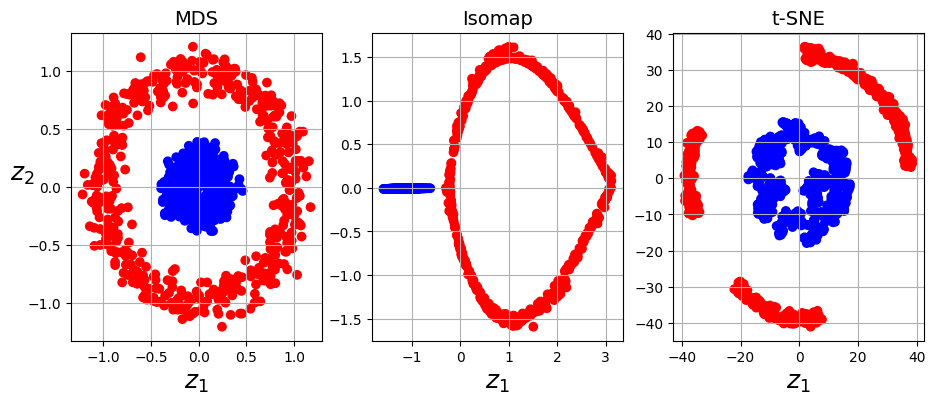

In [8]:
import matplotlib
titles = ["MDS", "Isomap", "t-SNE"]
colors = ["red", "blue"]

plt.figure(figsize=(11,4))

for subplot, title, X_reduced in zip((131, 132, 133), titles,
                                     (X_reduced_mds, X_reduced_isomap, X_reduced_tsne)):
    plt.subplot(subplot)
    plt.title(title, fontsize=14)
    plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y, cmap=matplotlib.colors.ListedColormap(colors))
    plt.xlabel("$z_1$", fontsize=18)
    if subplot == 131:
        plt.ylabel("$z_2$", fontsize=18, rotation=0)
    plt.grid(True)

plt.show()

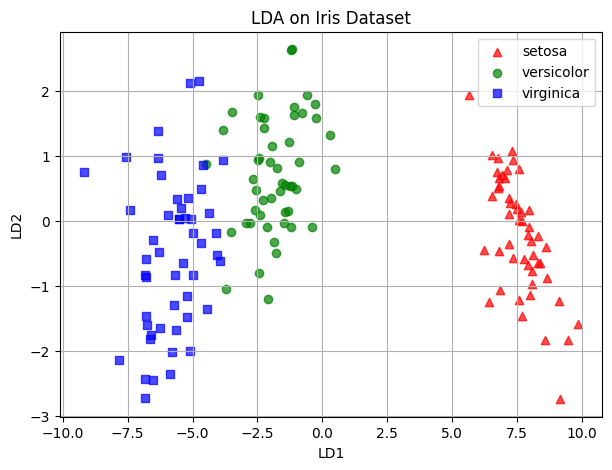

In [14]:
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.datasets import load_iris

# Iris 데이터 불러오기
iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X, y)

plt.figure(figsize=(7,5))
colors = ['red', 'green', 'blue']
markers = ['^', 'o', 's']

for i, color, marker in zip(range(3), colors, markers):
    plt.scatter(X_lda[y == i, 0], X_lda[y == i, 1], color=color, marker=marker, alpha=0.7, label=target_names[i])

plt.xlabel('LD1')
plt.ylabel('LD2')
plt.title('LDA on Iris Dataset')
plt.legend()
plt.grid(True)
plt.show()


**선형 판별 분석(LDA)**은 클래스 라벨을 사용하는 지도적 차원 축소 기법이다. 클래스 간 분산과 클래스 내 분산의 비를 최대화하는 방향으로 데이터를 사영하여, 클래스 분리가 최대가 되는 저차원 표현을 얻는다. 사영 축의 최대 개수는 (클래스 수 − 1)로 제한된다.